In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Wczytywanie i wstępne obrabianie danych do dalszej analizy

In [5]:
df_raw = pd.read_csv(f"penguins_lter.csv")

df_raw

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,PAL0910,120,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N38A2,No,12/1/09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
340,PAL0910,121,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A1,Yes,11/22/09,46.8,14.3,215.0,4850.0,FEMALE,8.41151,-26.13832,NaN
341,PAL0910,122,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A2,Yes,11/22/09,50.4,15.7,222.0,5750.0,MALE,8.30166,-26.04117,NaN
342,PAL0910,123,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N43A1,Yes,11/22/09,45.2,14.8,212.0,5200.0,FEMALE,8.24246,-26.11969,NaN


In [6]:
df_processed = df_raw.drop(
    columns="Stage\tstudyName\tRegion	Sample Number	Comments".split("\t")
).dropna()

df_processed

,Species,Island,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
1,Adelie Penguin (Pygoscelis adeliae),Torgersen,N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454
2,Adelie Penguin (Pygoscelis adeliae),Torgersen,N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302
4,Adelie Penguin (Pygoscelis adeliae),Torgersen,N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426
5,Adelie Penguin (Pygoscelis adeliae),Torgersen,N3A2,Yes,11/16/07,39.3,20.6,190.0,3650.0,MALE,8.66496,-25.29805
6,Adelie Penguin (Pygoscelis adeliae),Torgersen,N4A1,No,11/15/07,38.9,17.8,181.0,3625.0,FEMALE,9.18718,-25.21799
...,...,...,...,...,...,...,...,...,...,...,...,...
338,Gentoo penguin (Pygoscelis papua),Biscoe,N38A1,No,12/1/09,47.2,13.7,214.0,4925.0,FEMALE,7.99184,-26.20538
340,Gentoo penguin (Pygoscelis papua),Biscoe,N39A1,Yes,11/22/09,46.8,14.3,215.0,4850.0,FEMALE,8.41151,-26.13832
341,Gentoo penguin (Pygoscelis papua),Biscoe,N39A2,Yes,11/22/09,50.4,15.7,222.0,5750.0,MALE,8.30166,-26.04117
342,Gentoo penguin (Pygoscelis papua),Biscoe,N43A1,Yes,11/22/09,45.2,14.8,212.0,5200.0,FEMALE,8.24246,-26.11969


In [7]:
df_processed["Species"] = df_processed.apply(lambda x: re.sub(r" [P|p]enguin[\w ()]*", "",x["Species"]), axis=1)

df_processed

,Species,Island,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
1,Adelie,Torgersen,N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454
2,Adelie,Torgersen,N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302
4,Adelie,Torgersen,N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426
5,Adelie,Torgersen,N3A2,Yes,11/16/07,39.3,20.6,190.0,3650.0,MALE,8.66496,-25.29805
6,Adelie,Torgersen,N4A1,No,11/15/07,38.9,17.8,181.0,3625.0,FEMALE,9.18718,-25.21799
...,...,...,...,...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,N38A1,No,12/1/09,47.2,13.7,214.0,4925.0,FEMALE,7.99184,-26.20538
340,Gentoo,Biscoe,N39A1,Yes,11/22/09,46.8,14.3,215.0,4850.0,FEMALE,8.41151,-26.13832
341,Gentoo,Biscoe,N39A2,Yes,11/22/09,50.4,15.7,222.0,5750.0,MALE,8.30166,-26.04117
342,Gentoo,Biscoe,N43A1,Yes,11/22/09,45.2,14.8,212.0,5200.0,FEMALE,8.24246,-26.11969


In [8]:
df_processed["Date Egg"] = pd.to_datetime(df_processed["Date Egg"])

df_processed

/tmp/ipykernel_3386733/3041332478.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_processed["Date Egg"] = pd.to_datetime(df_processed["Date Egg"])


,Species,Island,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
1,Adelie,Torgersen,N1A2,Yes,2007-11-11,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454
2,Adelie,Torgersen,N2A1,Yes,2007-11-16,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302
4,Adelie,Torgersen,N3A1,Yes,2007-11-16,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426
5,Adelie,Torgersen,N3A2,Yes,2007-11-16,39.3,20.6,190.0,3650.0,MALE,8.66496,-25.29805
6,Adelie,Torgersen,N4A1,No,2007-11-15,38.9,17.8,181.0,3625.0,FEMALE,9.18718,-25.21799
...,...,...,...,...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,N38A1,No,2009-12-01,47.2,13.7,214.0,4925.0,FEMALE,7.99184,-26.20538
340,Gentoo,Biscoe,N39A1,Yes,2009-11-22,46.8,14.3,215.0,4850.0,FEMALE,8.41151,-26.13832
341,Gentoo,Biscoe,N39A2,Yes,2009-11-22,50.4,15.7,222.0,5750.0,MALE,8.30166,-26.04117
342,Gentoo,Biscoe,N43A1,Yes,2009-11-22,45.2,14.8,212.0,5200.0,FEMALE,8.24246,-26.11969


In [9]:
first_variables = "Individual ID\tSpecies\tIsland\tClutch Completion\tSex\tDate Egg".split("\t")

df = df_processed[first_variables + [
    col for col in df_processed.columns if col not in set(first_variables)
]]

df = df[df["Sex"]!="."]

df

,Individual ID,Species,Island,Clutch Completion,Sex,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
1,N1A2,Adelie,Torgersen,Yes,FEMALE,2007-11-11,39.5,17.4,186.0,3800.0,8.94956,-24.69454
2,N2A1,Adelie,Torgersen,Yes,FEMALE,2007-11-16,40.3,18.0,195.0,3250.0,8.36821,-25.33302
4,N3A1,Adelie,Torgersen,Yes,FEMALE,2007-11-16,36.7,19.3,193.0,3450.0,8.76651,-25.32426
5,N3A2,Adelie,Torgersen,Yes,MALE,2007-11-16,39.3,20.6,190.0,3650.0,8.66496,-25.29805
6,N4A1,Adelie,Torgersen,No,FEMALE,2007-11-15,38.9,17.8,181.0,3625.0,9.18718,-25.21799
...,...,...,...,...,...,...,...,...,...,...,...,...
338,N38A1,Gentoo,Biscoe,No,FEMALE,2009-12-01,47.2,13.7,214.0,4925.0,7.99184,-26.20538
340,N39A1,Gentoo,Biscoe,Yes,FEMALE,2009-11-22,46.8,14.3,215.0,4850.0,8.41151,-26.13832
341,N39A2,Gentoo,Biscoe,Yes,MALE,2009-11-22,50.4,15.7,222.0,5750.0,8.30166,-26.04117
342,N43A1,Gentoo,Biscoe,Yes,FEMALE,2009-11-22,45.2,14.8,212.0,5200.0,8.24246,-26.11969


# Wizualizacja Danych (przed obróbką)

In [10]:
from typing import Literal

In [11]:
categorical_variables = first_variables[1:-1]

categorical_variables

['Species', 'Island', 'Clutch Completion', 'Sex']

In [12]:
numerical_variables = "Culmen Length (mm)	Culmen Depth (mm)	Flipper Length (mm)	Body Mass (g)	Delta 15 N (o/oo)	Delta 13 C (o/oo)".split("\t")

numerical_variables

['Culmen Length (mm)',
 'Culmen Depth (mm)',
 'Flipper Length (mm)',
 'Body Mass (g)',
 'Delta 15 N (o/oo)',
 'Delta 13 C (o/oo)']

### Bonus: Wykresy Kropkowe (z KDE zamiast histogramów)

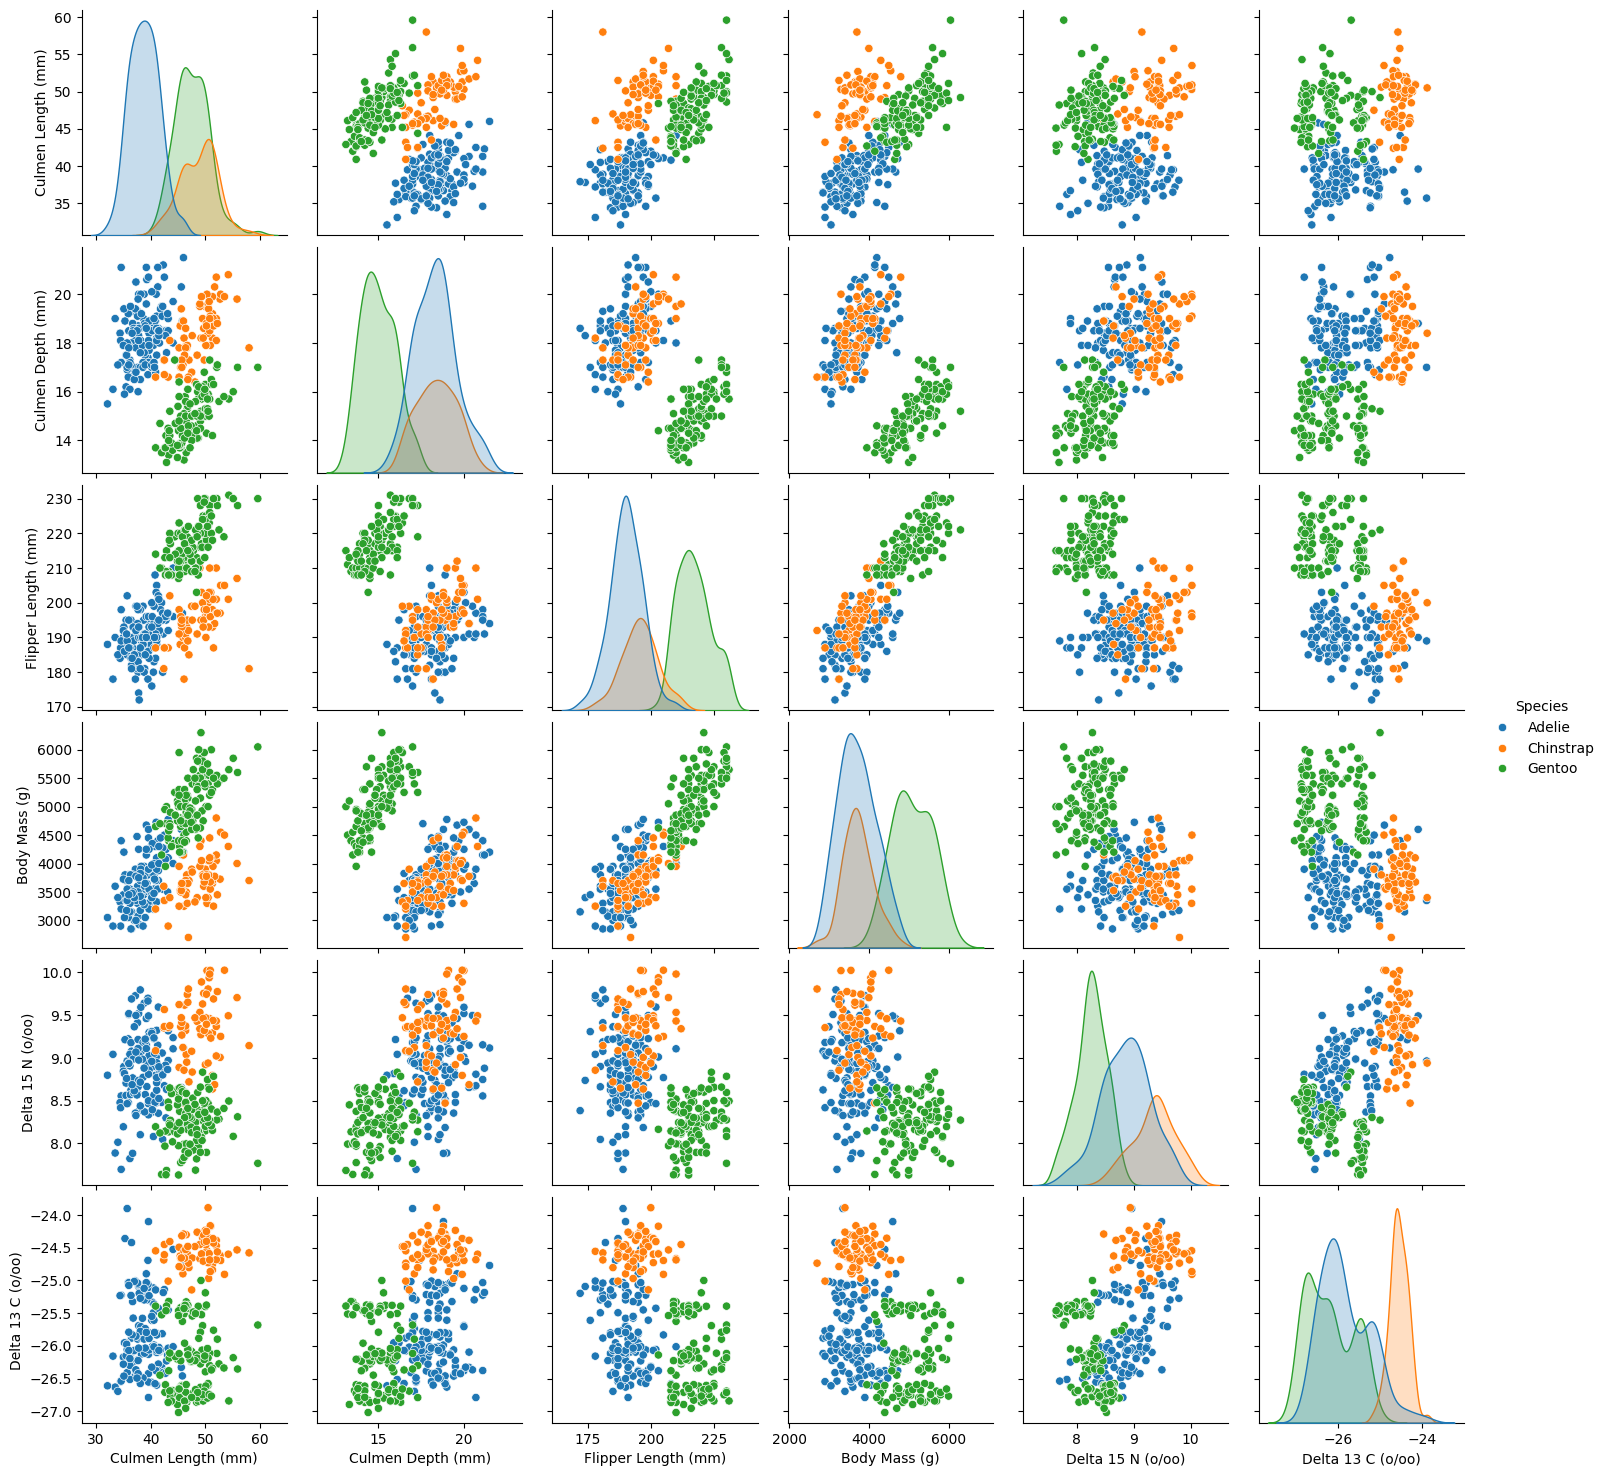

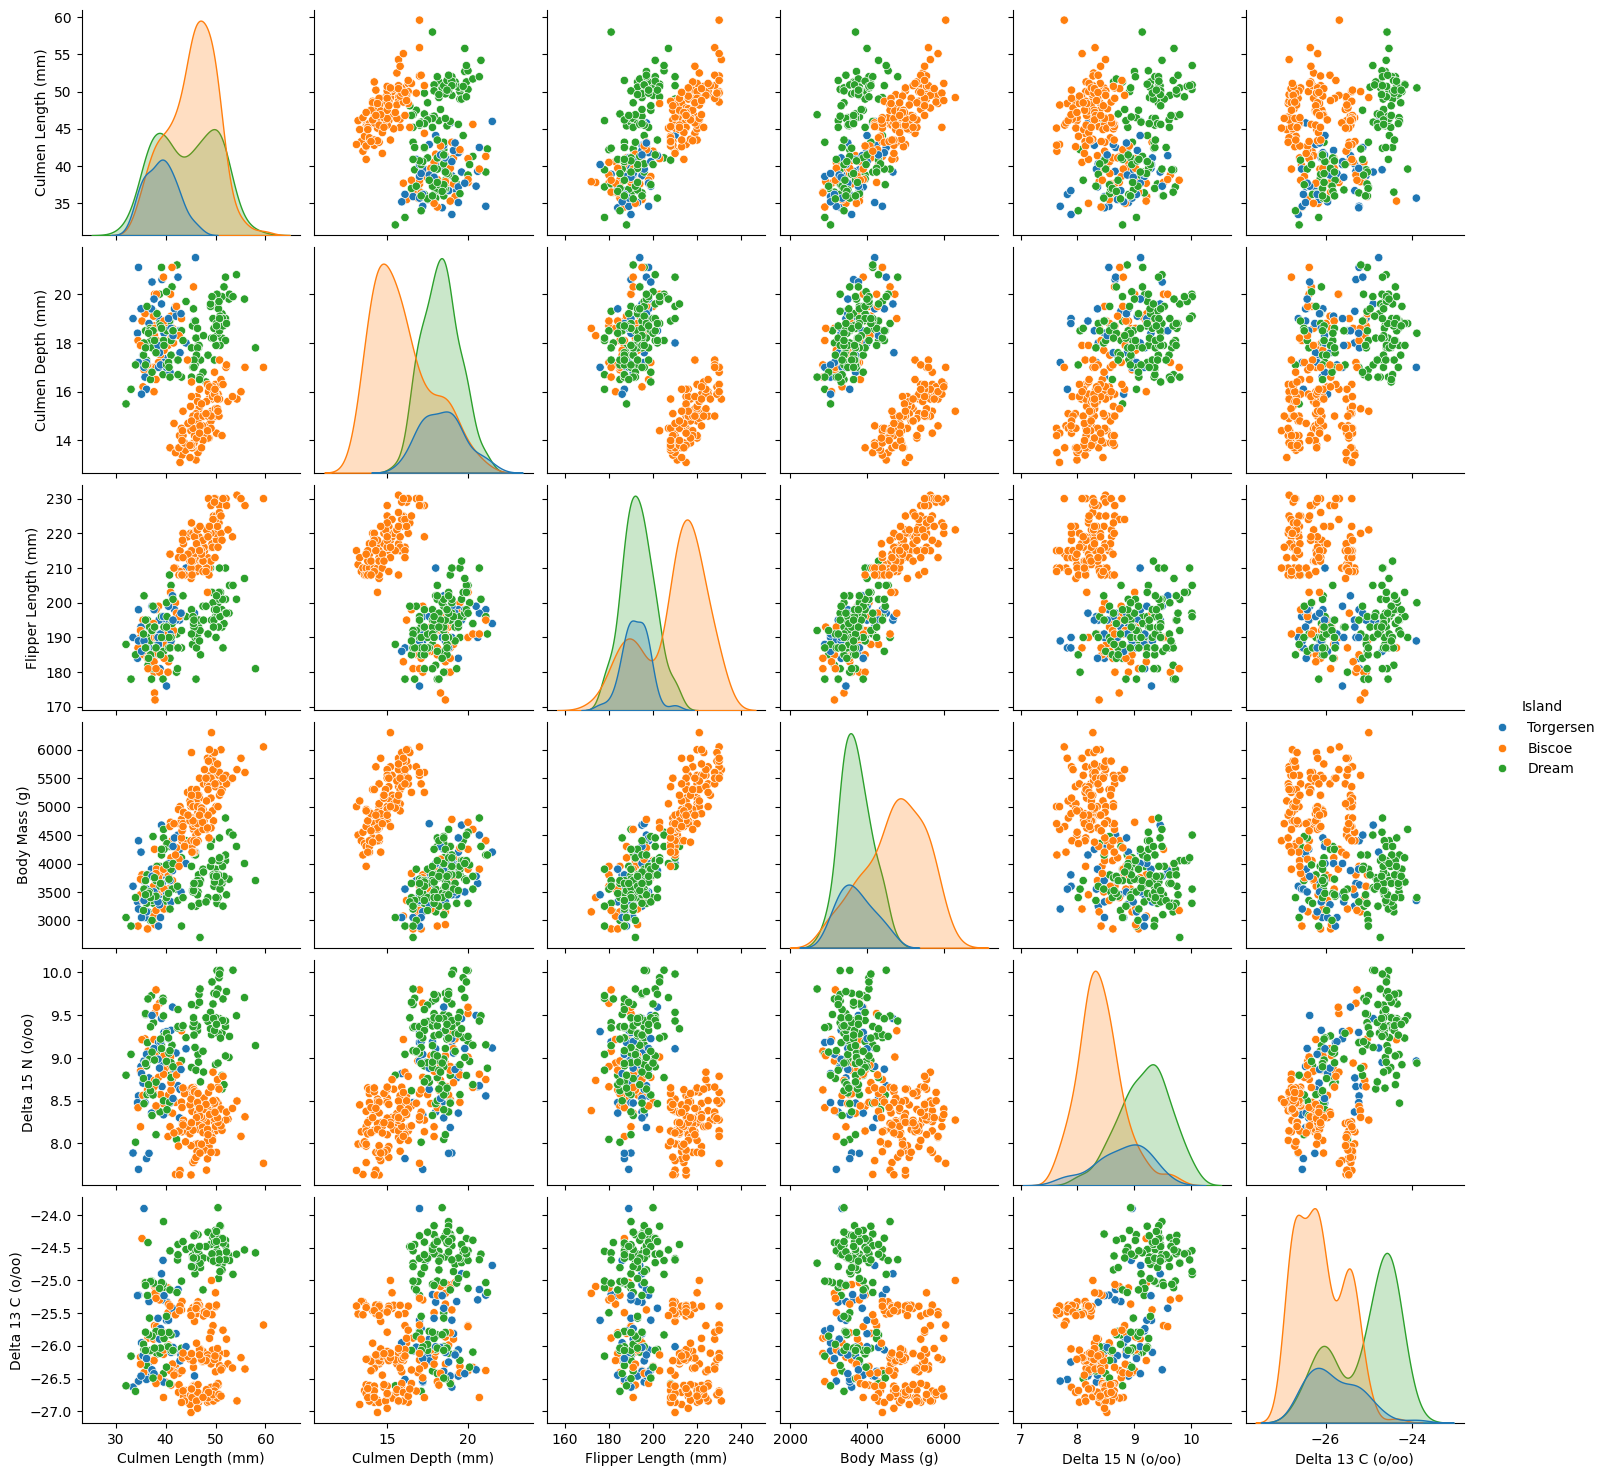

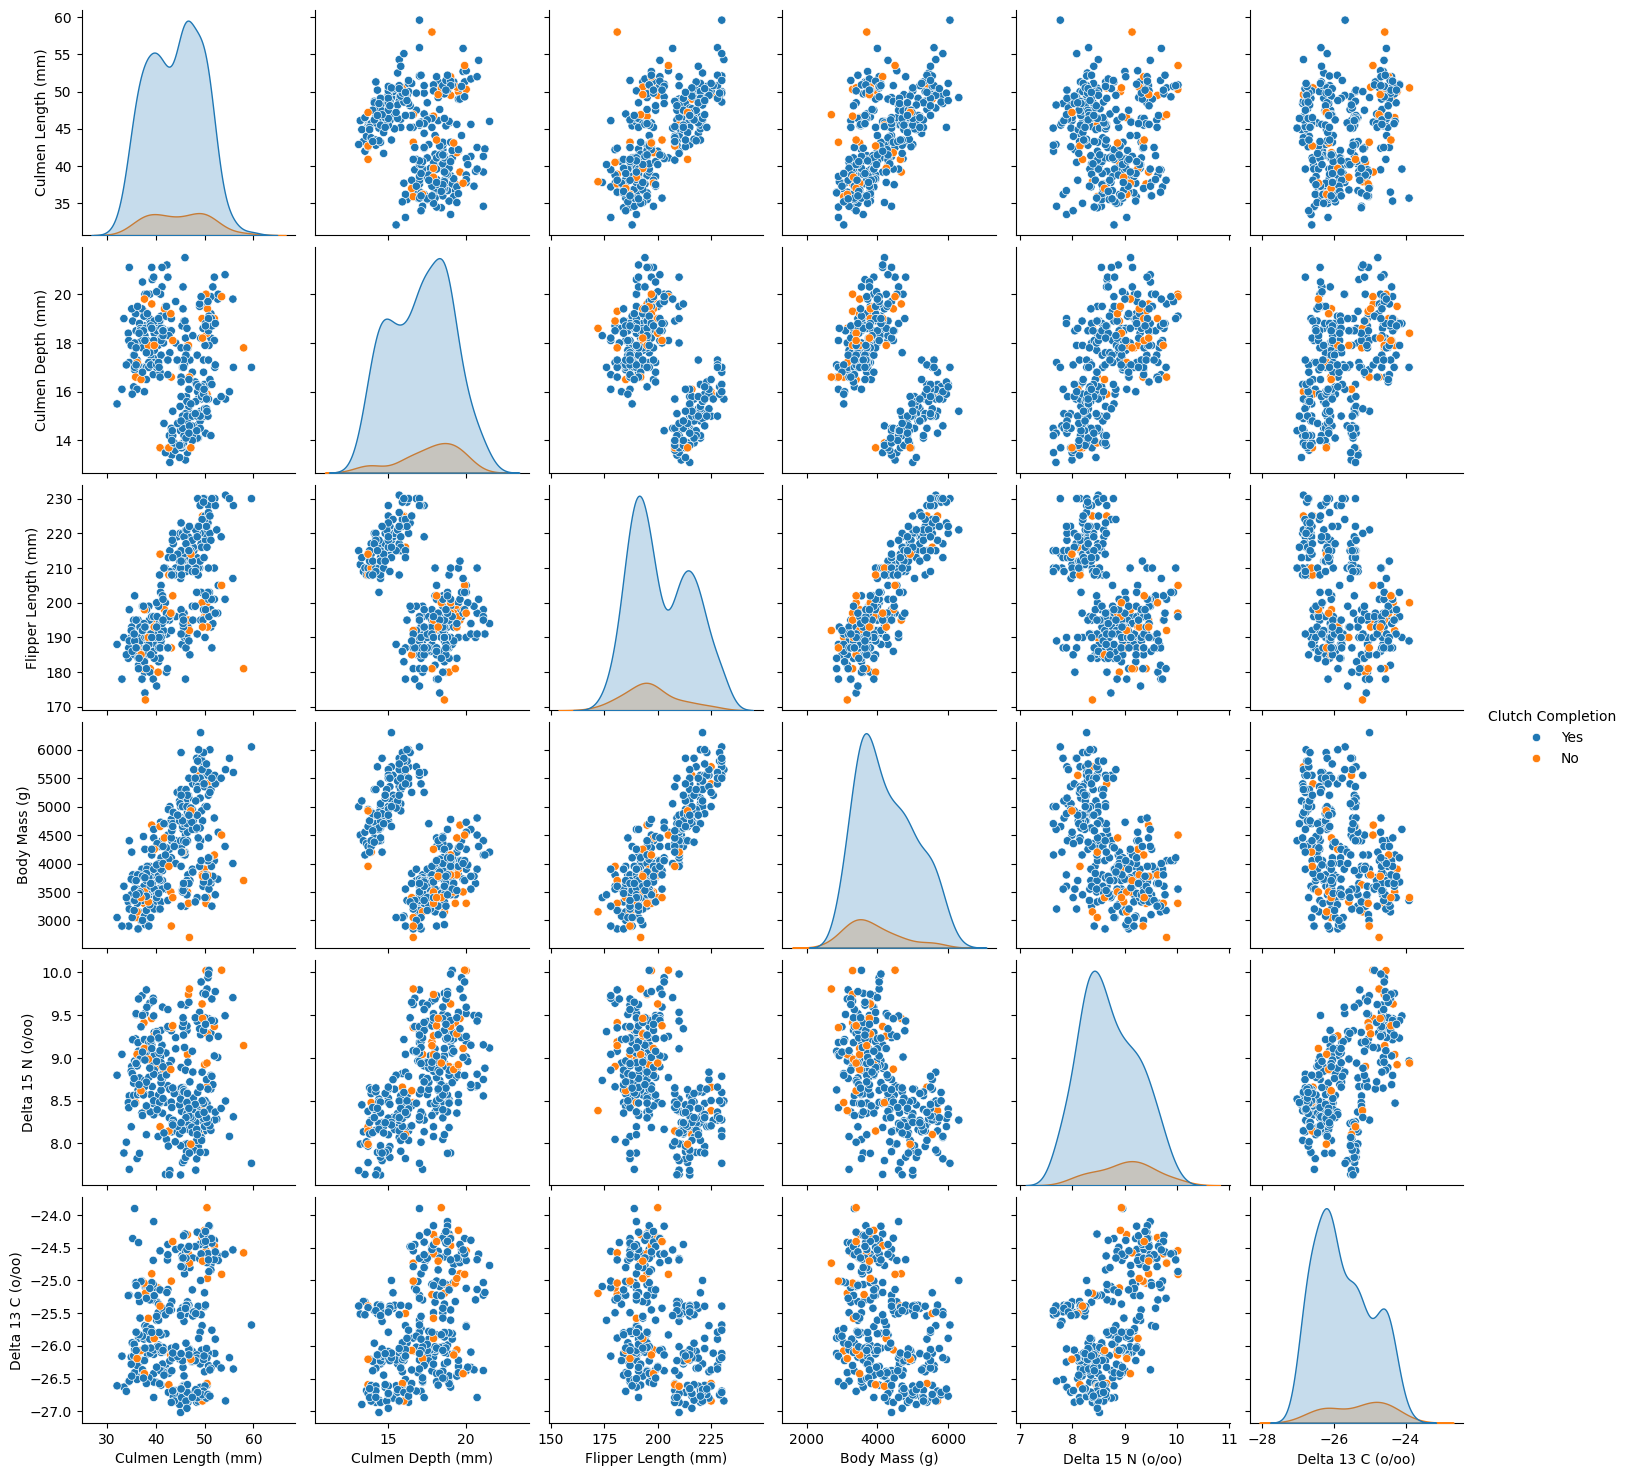

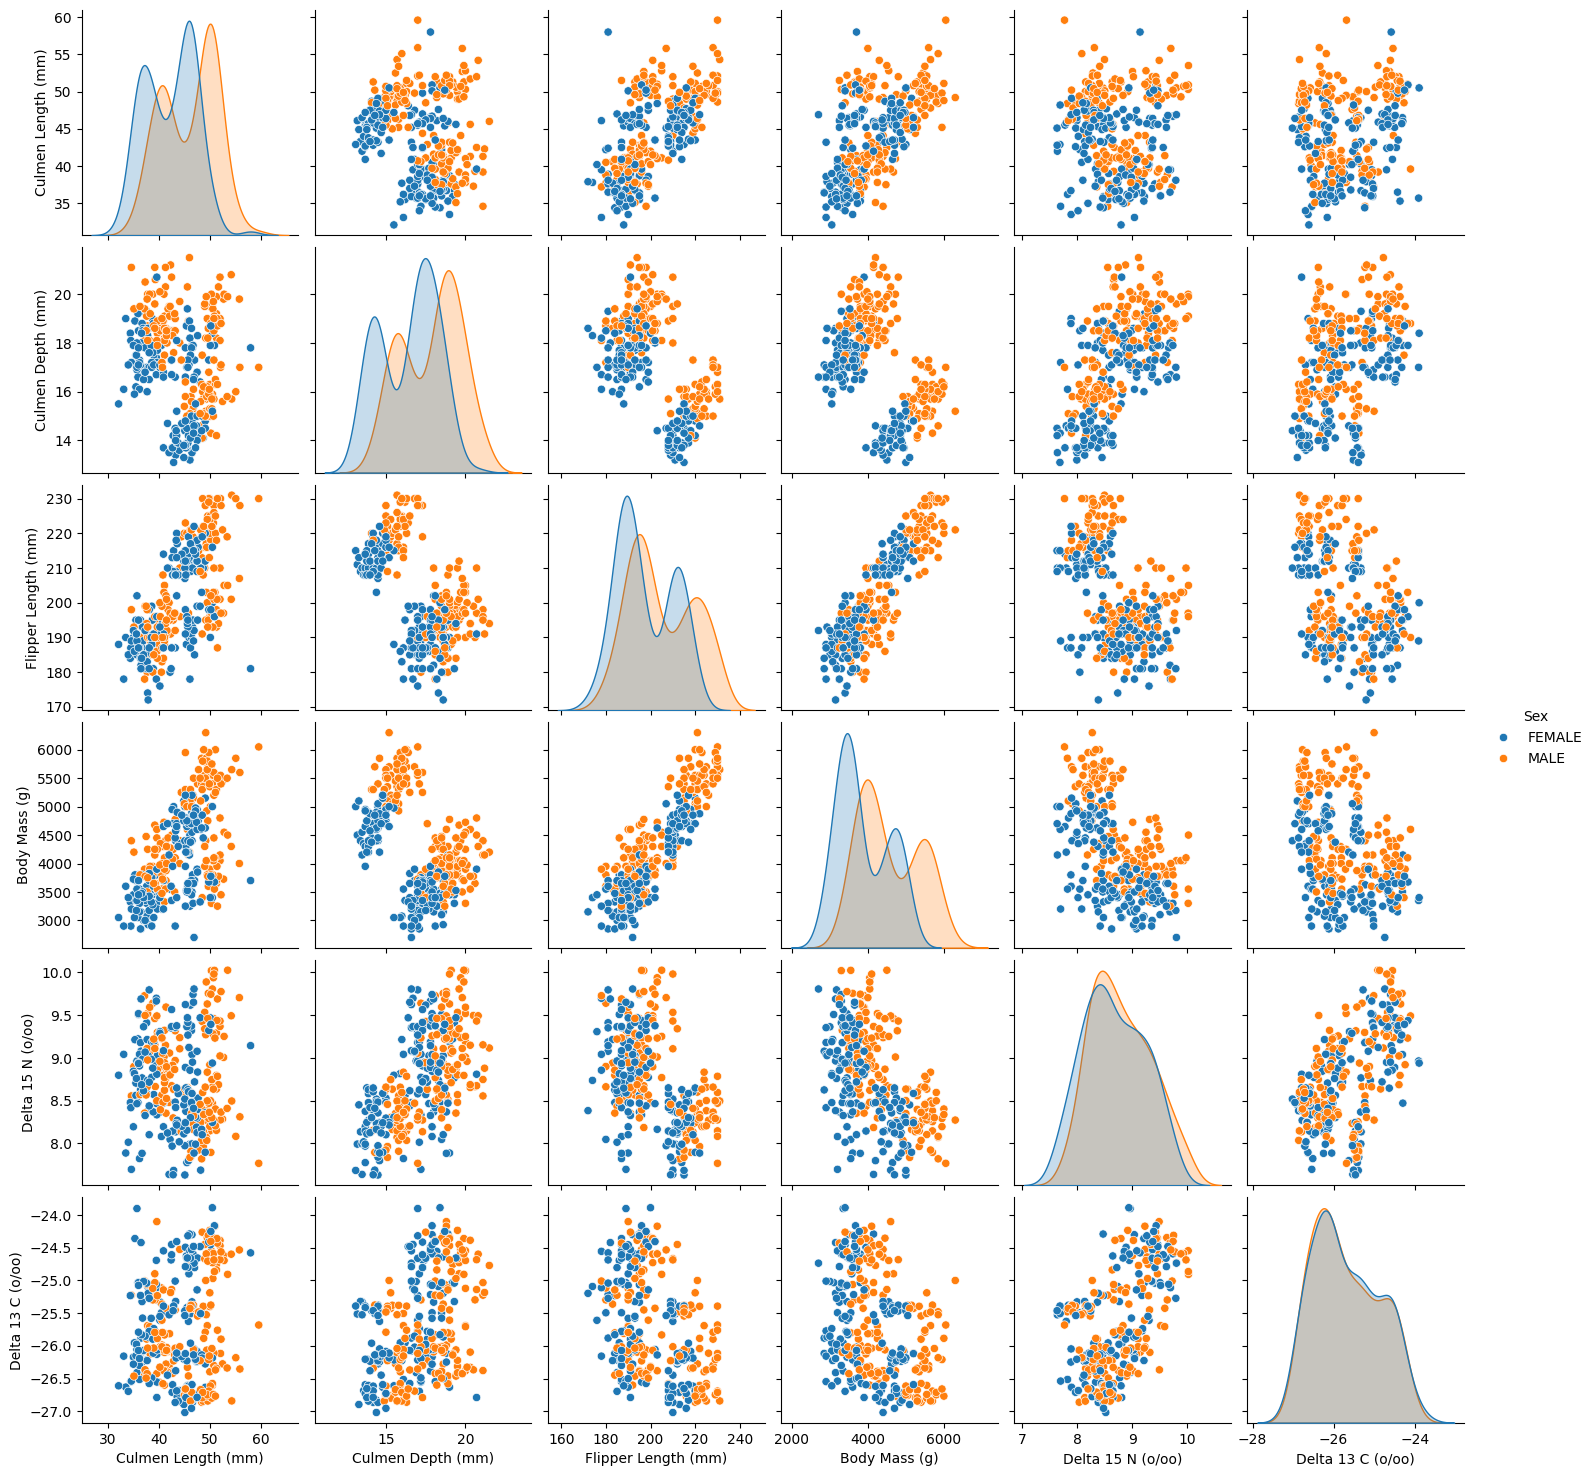

In [13]:
for cat_var in categorical_variables:
    sns.pairplot(
        df,
        hue=cat_var
    )

## Zmienne Ilościowe

In [ ]:
def plot_numerical_variable(
        plot_func, 
        df:pd.DataFrame, 
        cols_included: list[str], 
        figsize_reversed: bool = False,
        hue: Literal['Species', 'Island', 'Clutch Completion', 'Sex']|None = None,
    ) -> None:
    if figsize_reversed == False:
        fig, axs = plt.subplots(len(cols_included), figsize = (12, 3*len(cols_included)))
    else:
        fig, axs = plt.subplots(1, len(cols_included), figsize = (3*len(cols_included), 12))

    for ax_idx, num_var in enumerate(cols_included):
        if plot_func != sns.histplot:
            if hue is not None:
                plot_func(ax = axs[ax_idx], data = df[[num_var, hue]], x = num_var, hue=hue)
            else:
                plot_func(ax = axs[ax_idx], data = df[num_var])
        else:
            if hue is not None:
                plot_func(ax = axs[ax_idx], data = df[[num_var, hue]], x = num_var, hue=hue, multiple="dodge", shrink = 0.9)
            else:
                plot_func(ax = axs[ax_idx], data = df[num_var], multiple="dodge", shrink = 0.9)
        axs[ax_idx].grid(True, ls = "--")

    fig.tight_layout()

### Histogramy

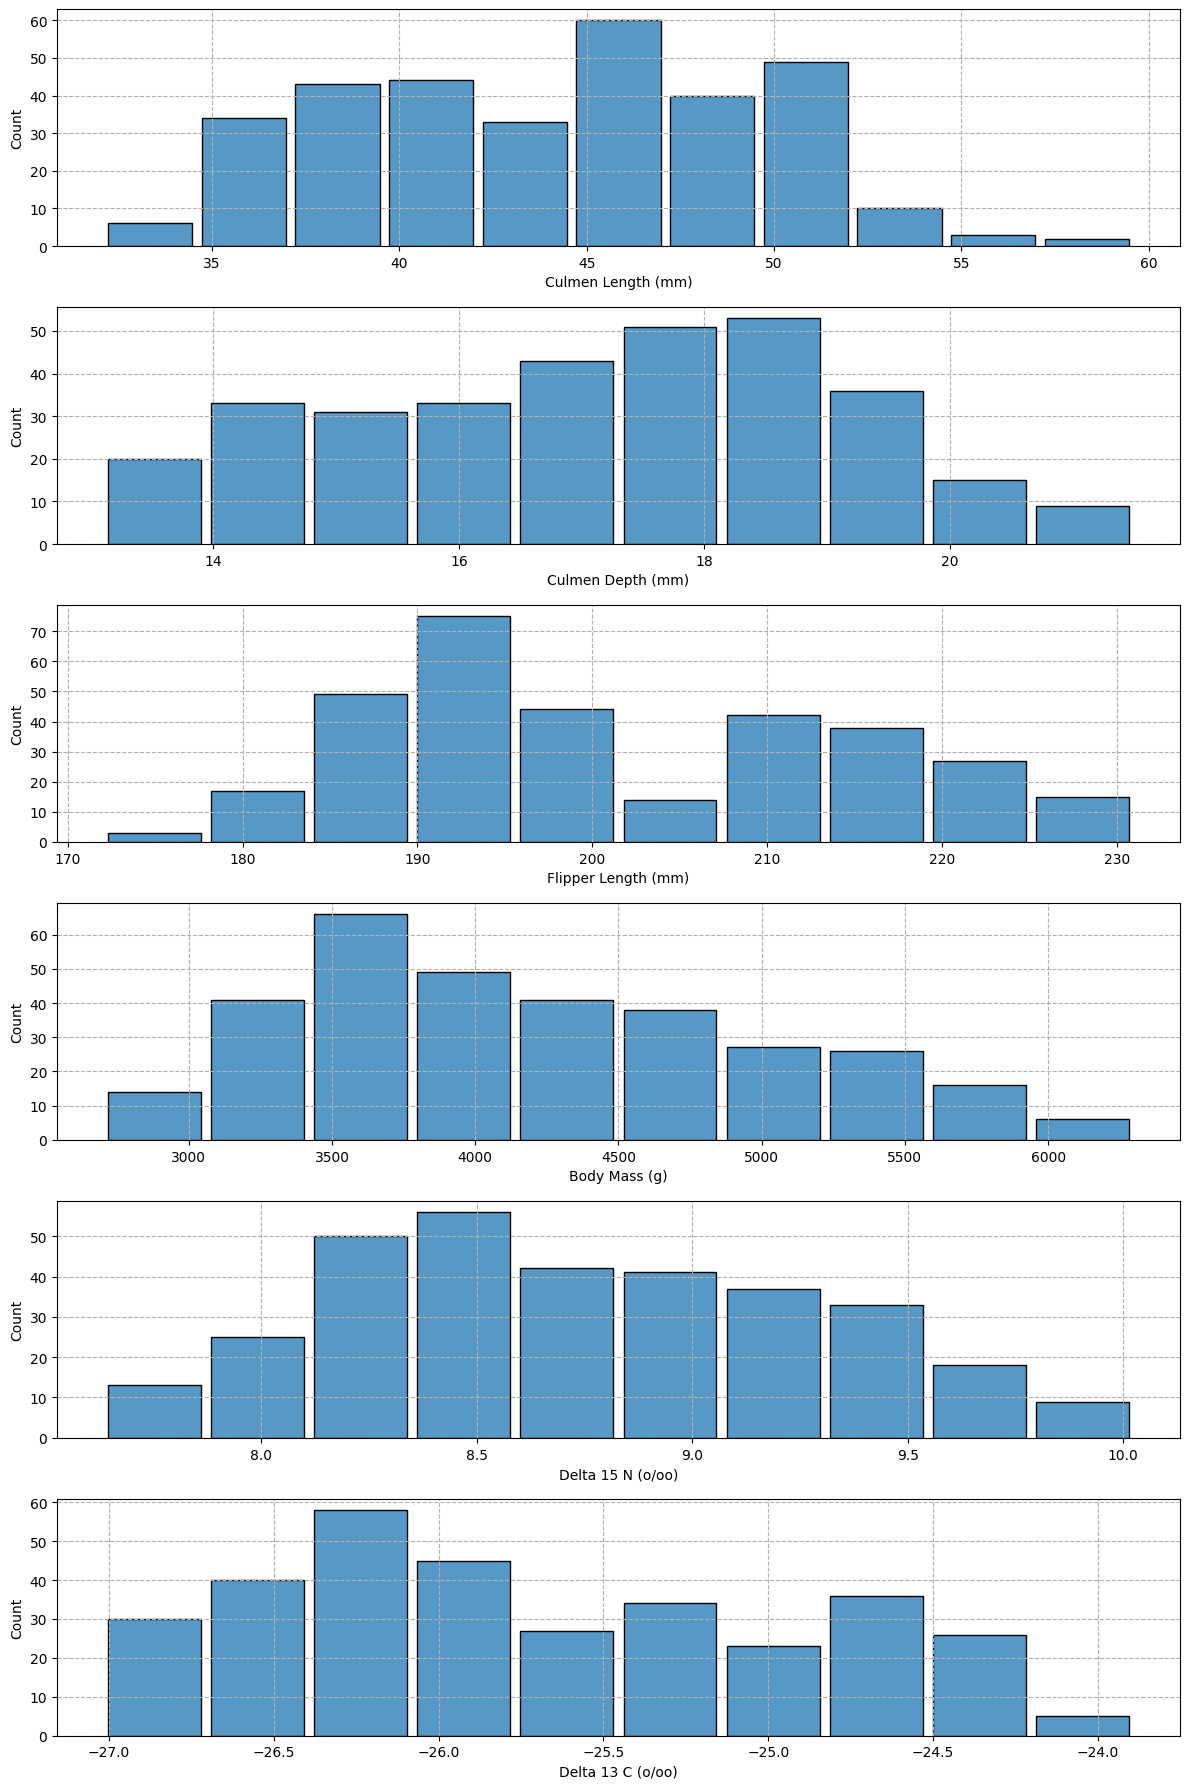

In [15]:
plot_numerical_variable(
    sns.histplot,
    df,
    numerical_variables,
    False
)

### Dystrybuanty Empriczyne

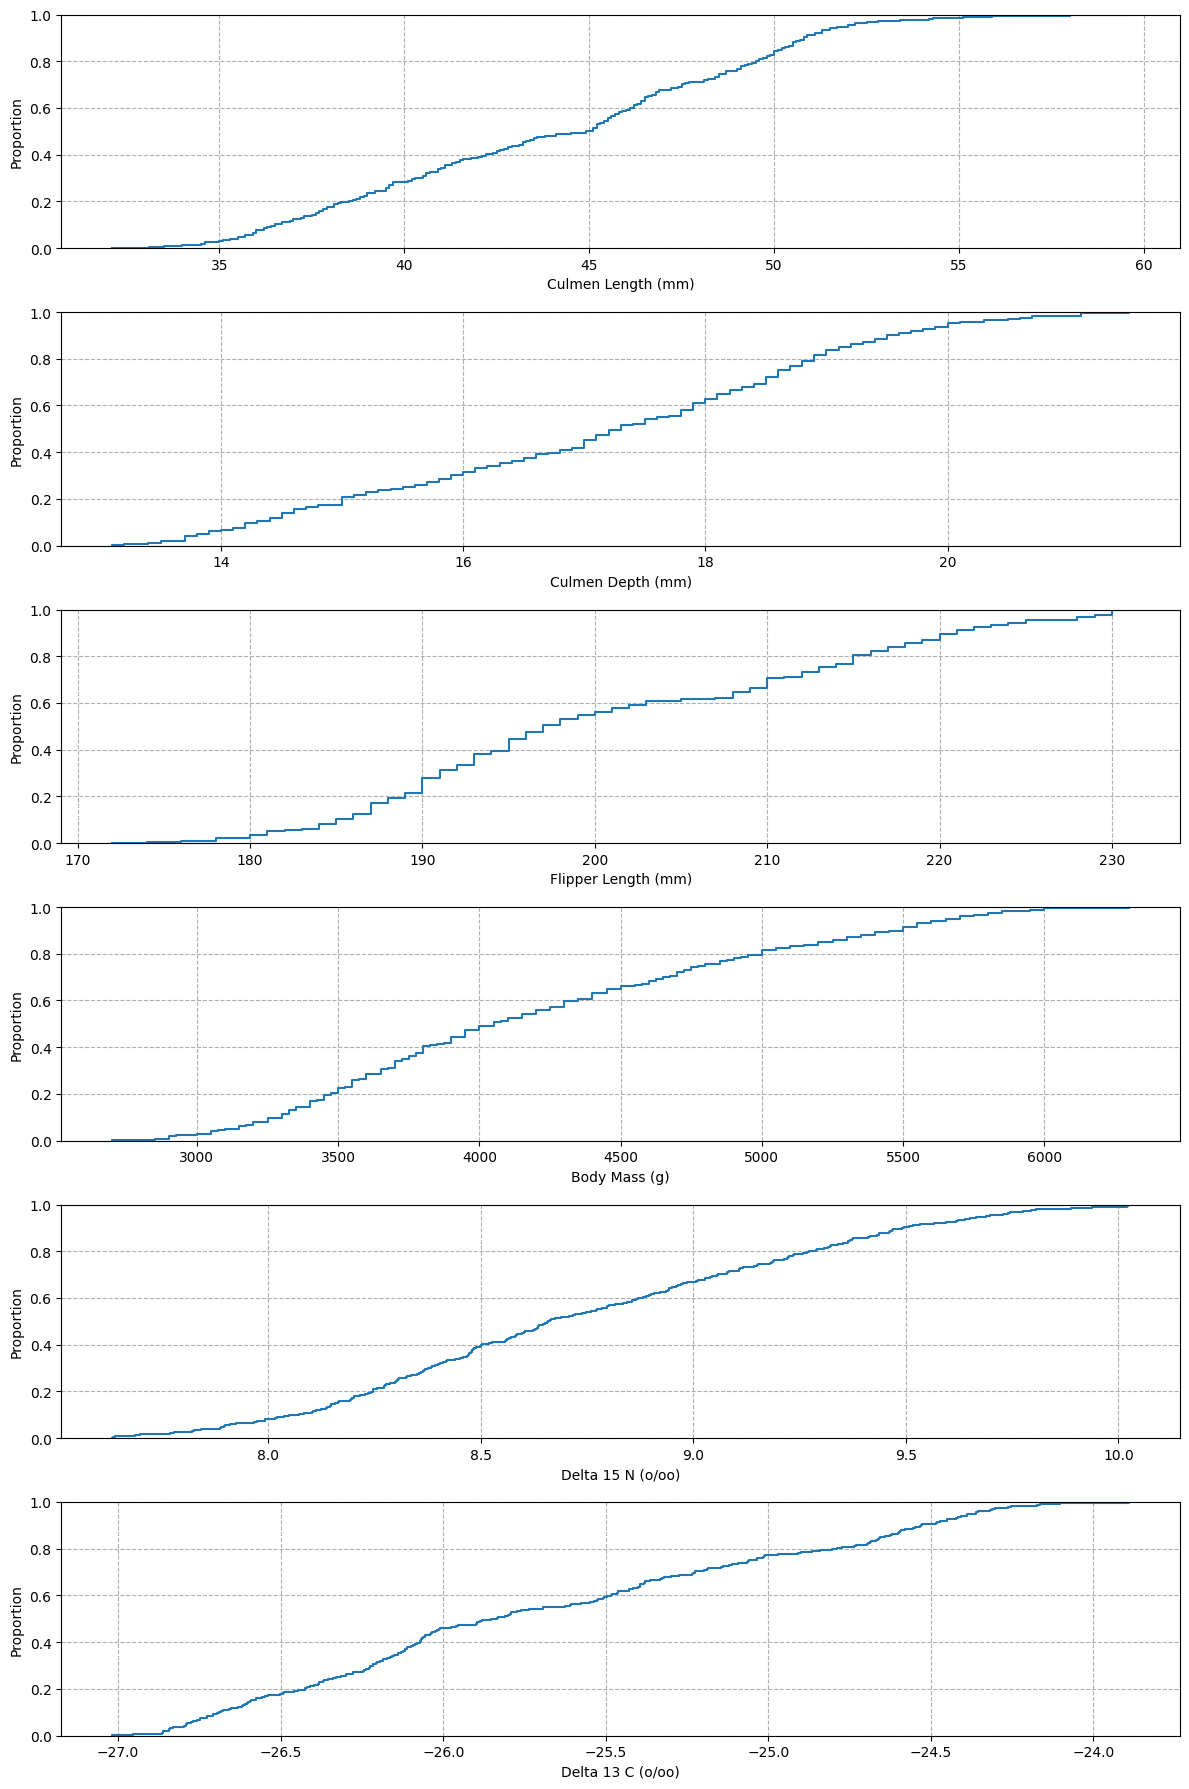

In [16]:
plot_numerical_variable(
    sns.ecdfplot,
    df, 
    numerical_variables,
    False
)

### Wykresy Wiolinowe

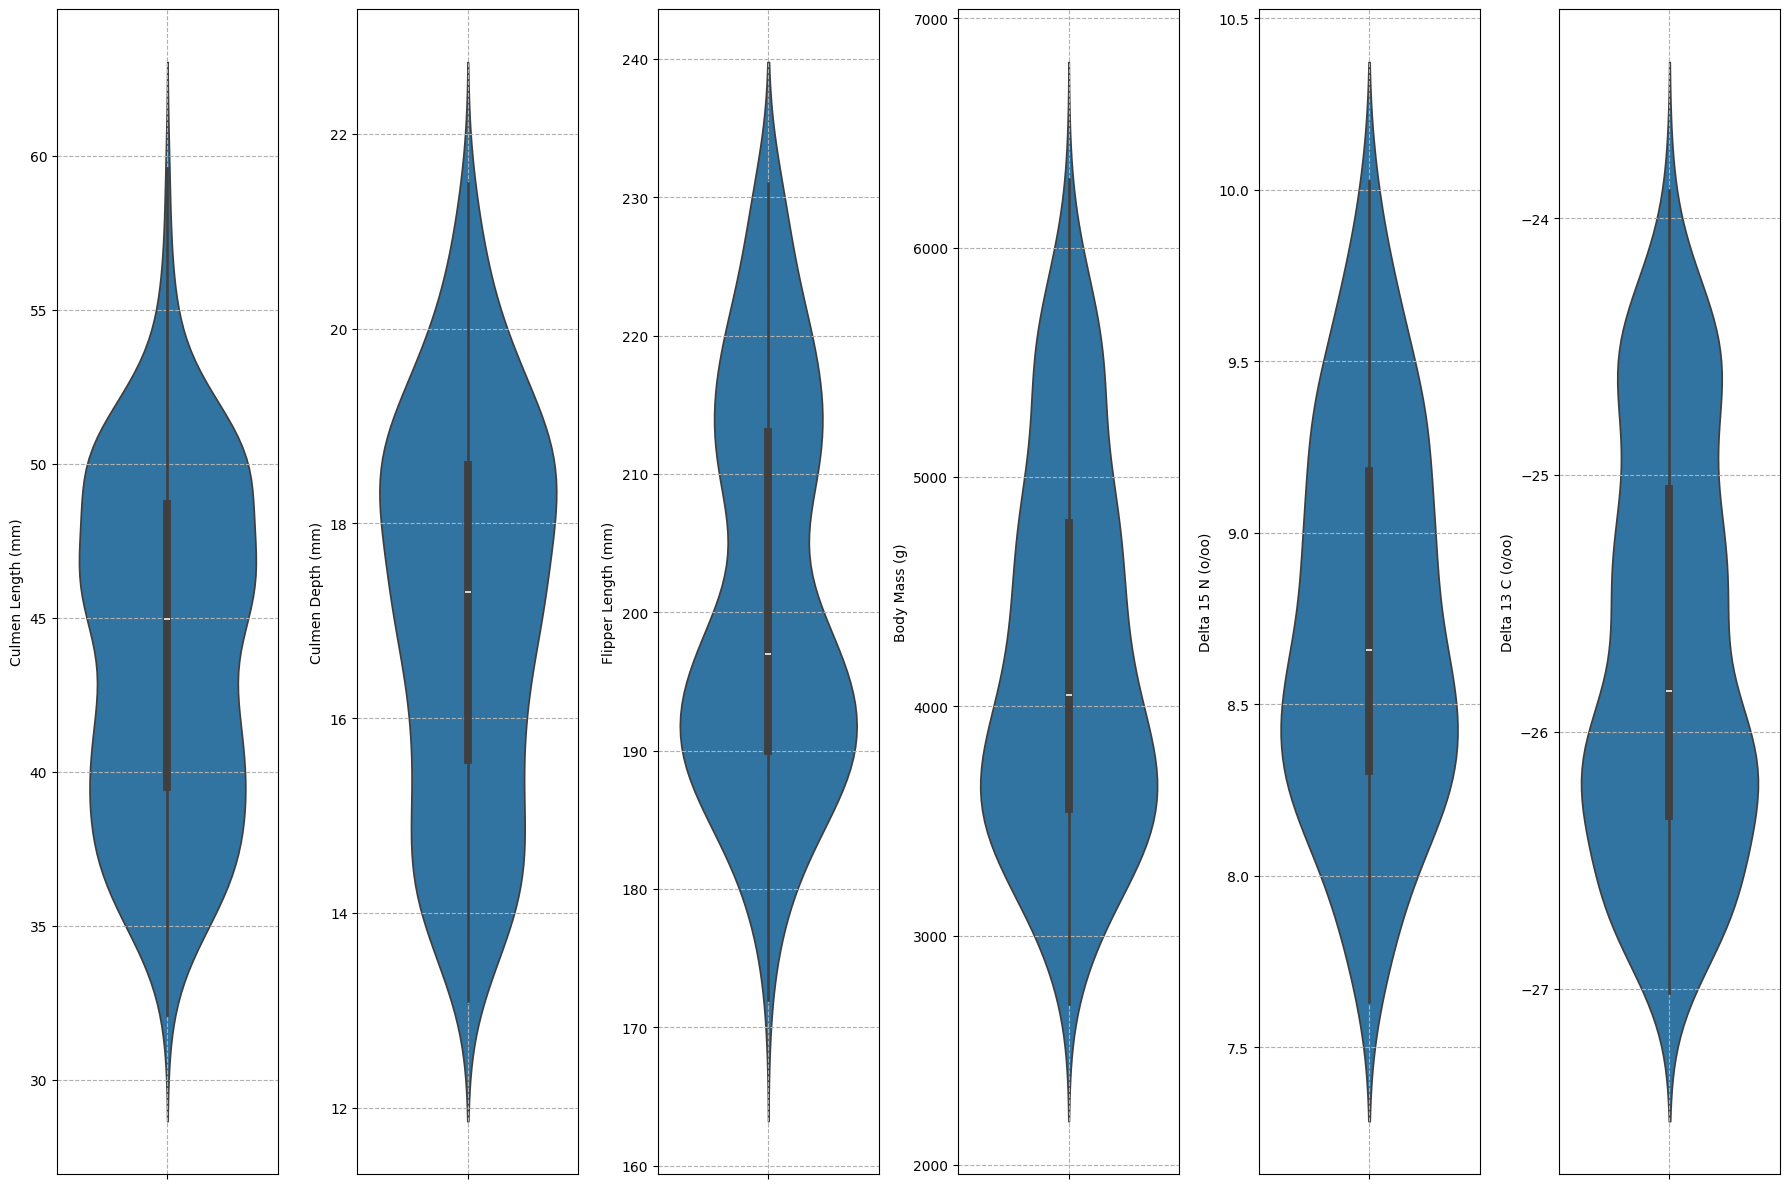

In [17]:
plot_numerical_variable(
    sns.violinplot,
    df, 
    numerical_variables,
    True
)

### Wykresy Pudełkowe (Box-Plots)

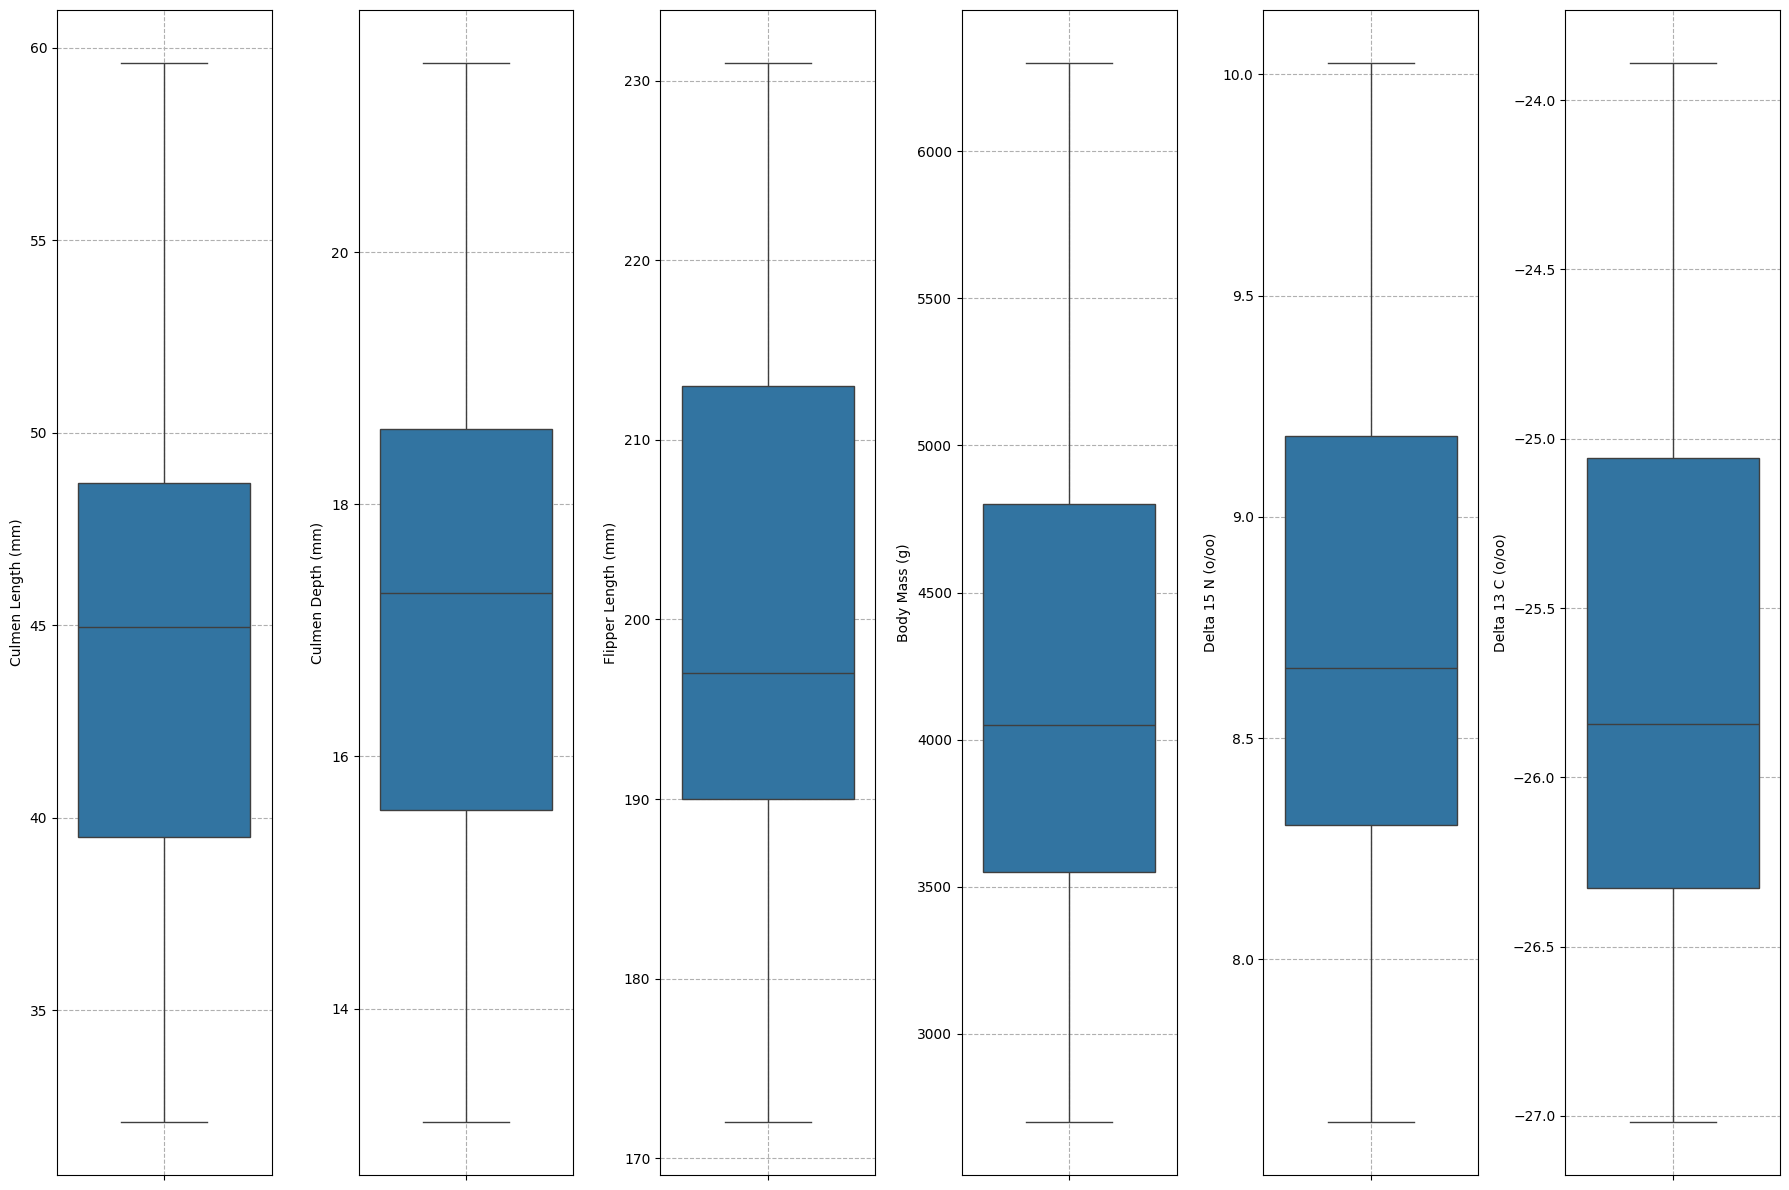

In [18]:
plot_numerical_variable(
    sns.boxplot,
    df,
    numerical_variables,
    True
)

## Zmienne Jakościowe

In [19]:
def plot_categorical_variable(
        df:pd.DataFrame, 
        cols_included: list[str], 
        x_category: Literal['Species', 'Island', 'Clutch Completion', 'Sex'], 
        hue: Literal['Species', 'Island', 'Clutch Completion', 'Sex'], 
        kind: Literal['strip', 'swarm', 'box', 'violin', 'boxen', 'point', 'bar', 'count']
    ) -> None:

    for ax_idx, num_var in enumerate(cols_included):
        sns.catplot(
            data=df,
            x = x_category,
            hue=hue,
            y = num_var,
            kind=kind,
        )
        plt.grid(True, ls = "--")


### Histogram

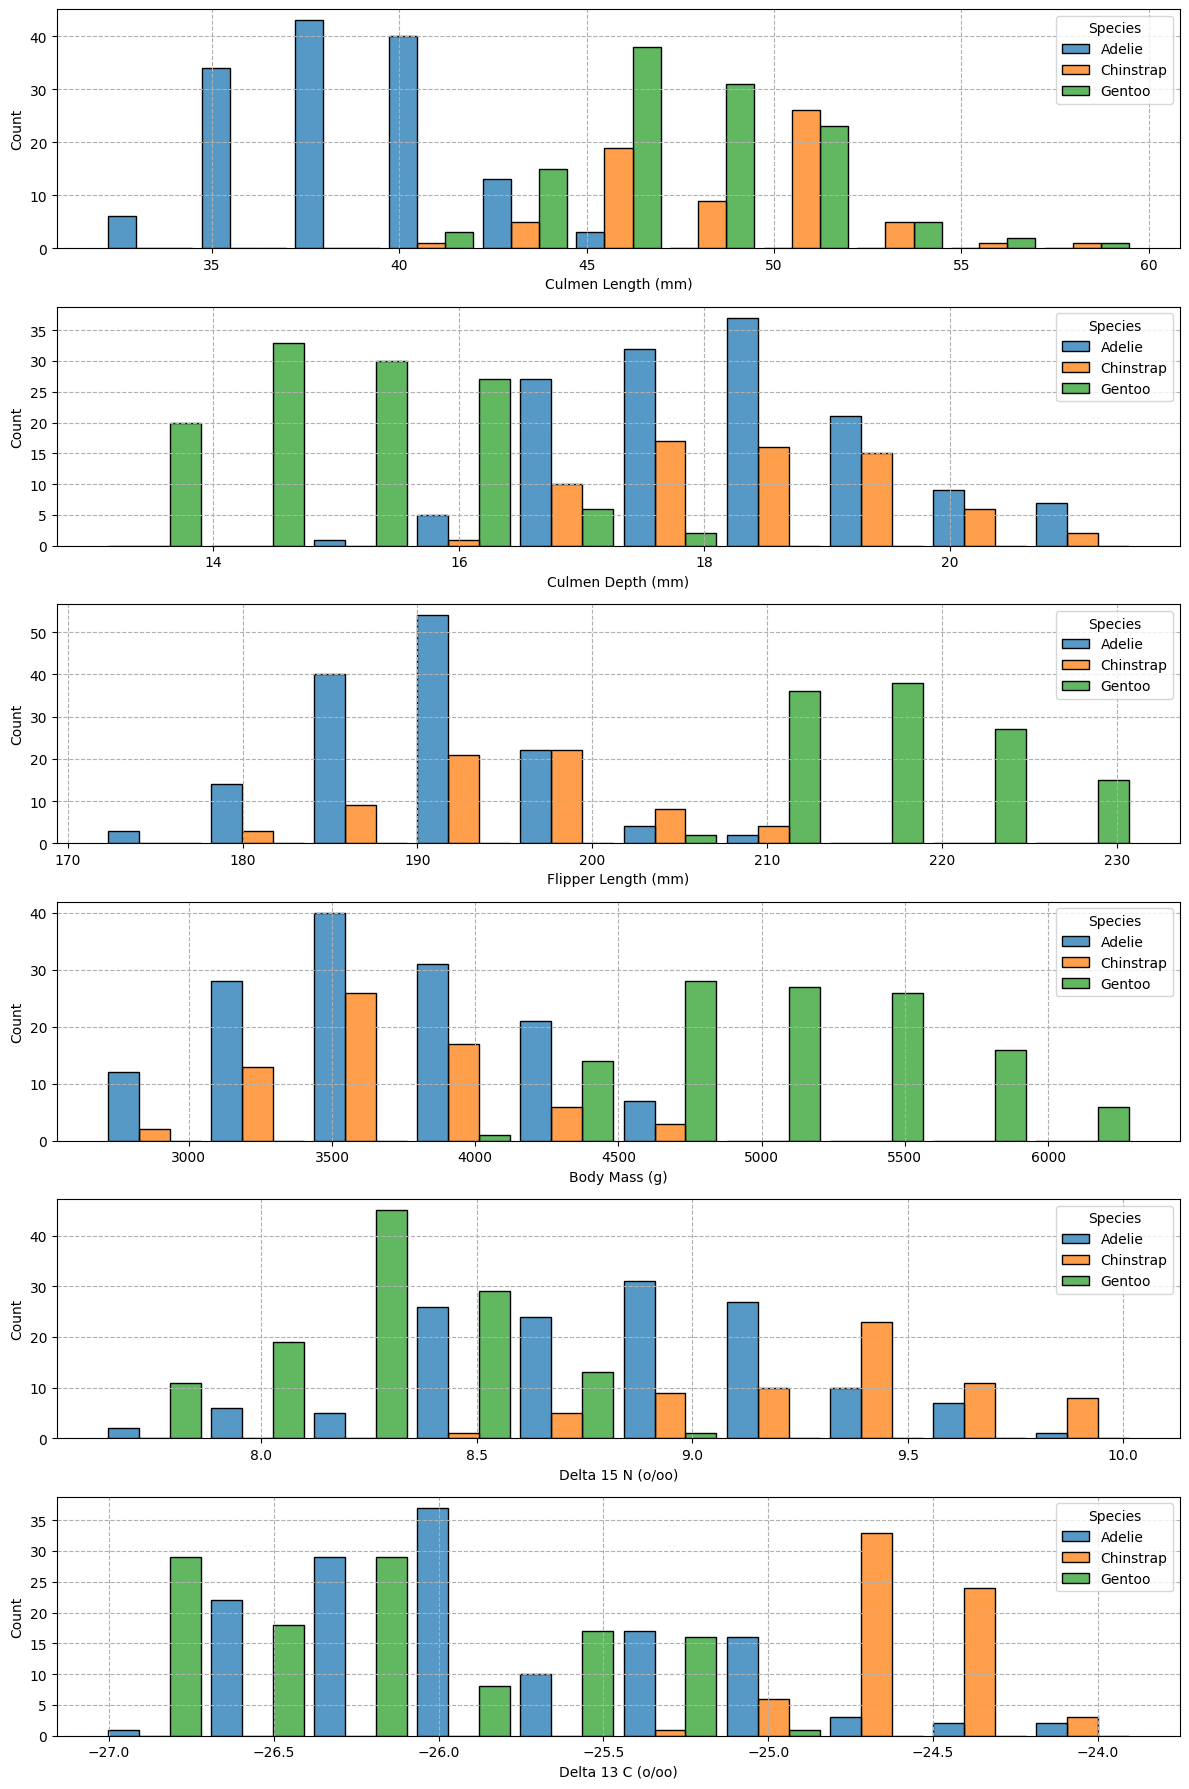

In [20]:
plot_numerical_variable(
    sns.histplot,
    df, 
    numerical_variables,
    hue="Species",
)

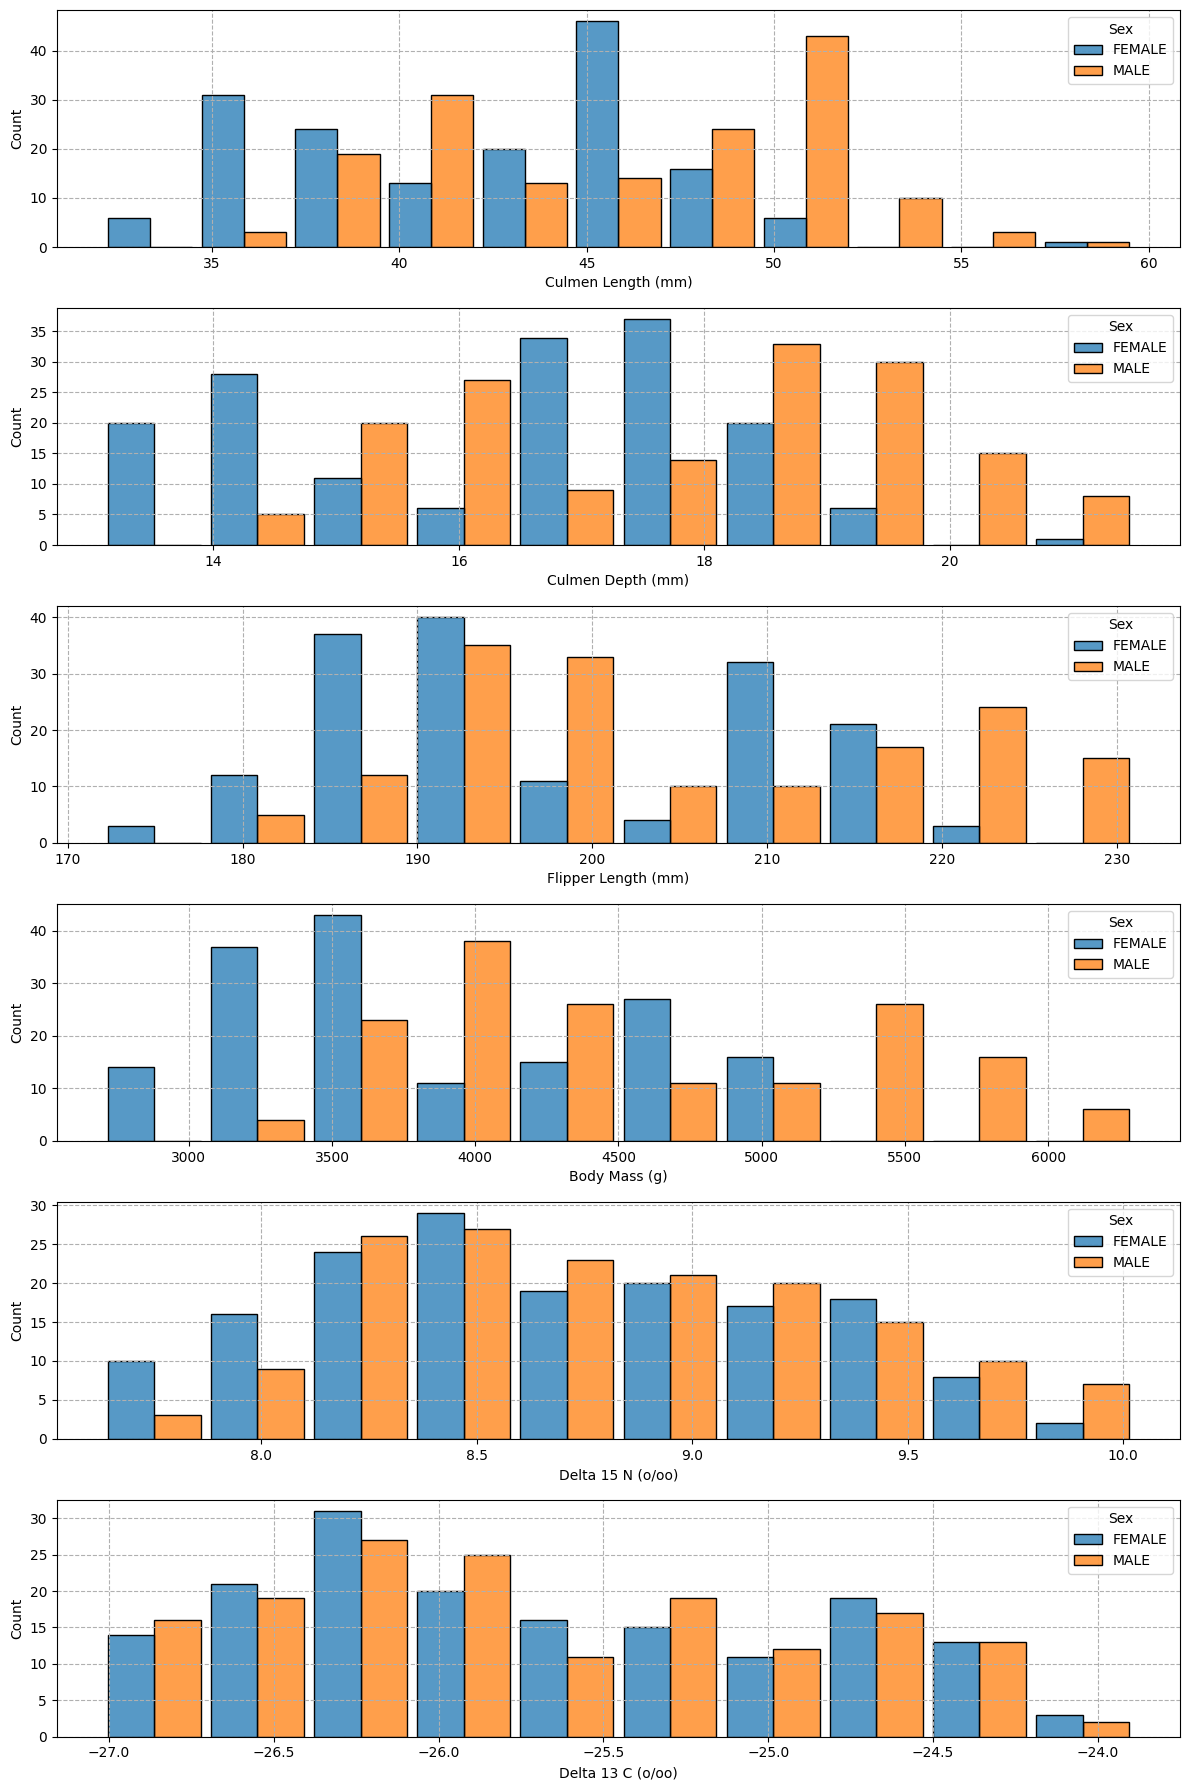

In [21]:
plot_numerical_variable(
    sns.histplot,
    df, 
    numerical_variables,
    hue="Sex",
)

### Dytrybuanty Empiryczne

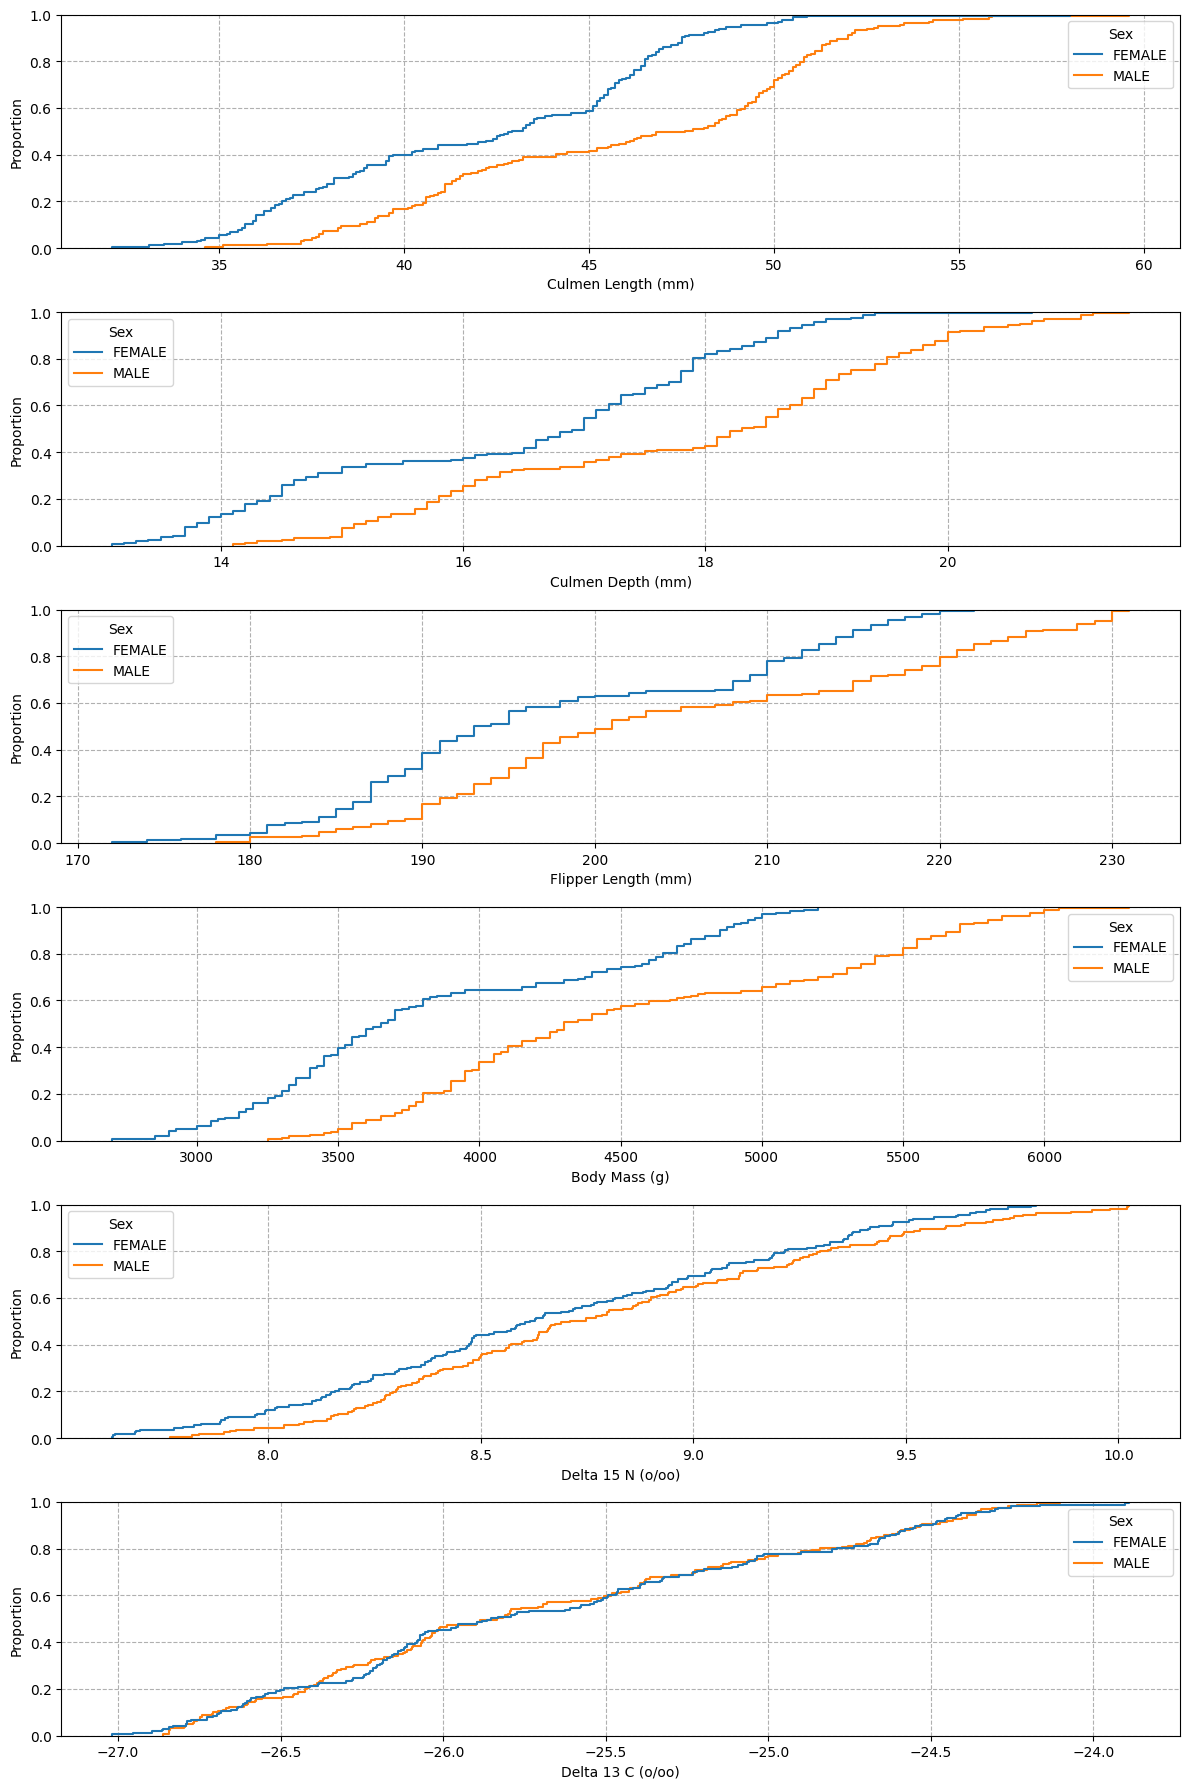

In [22]:
plot_numerical_variable(
    sns.ecdfplot,
    df, 
    numerical_variables,
    hue="Sex"
)

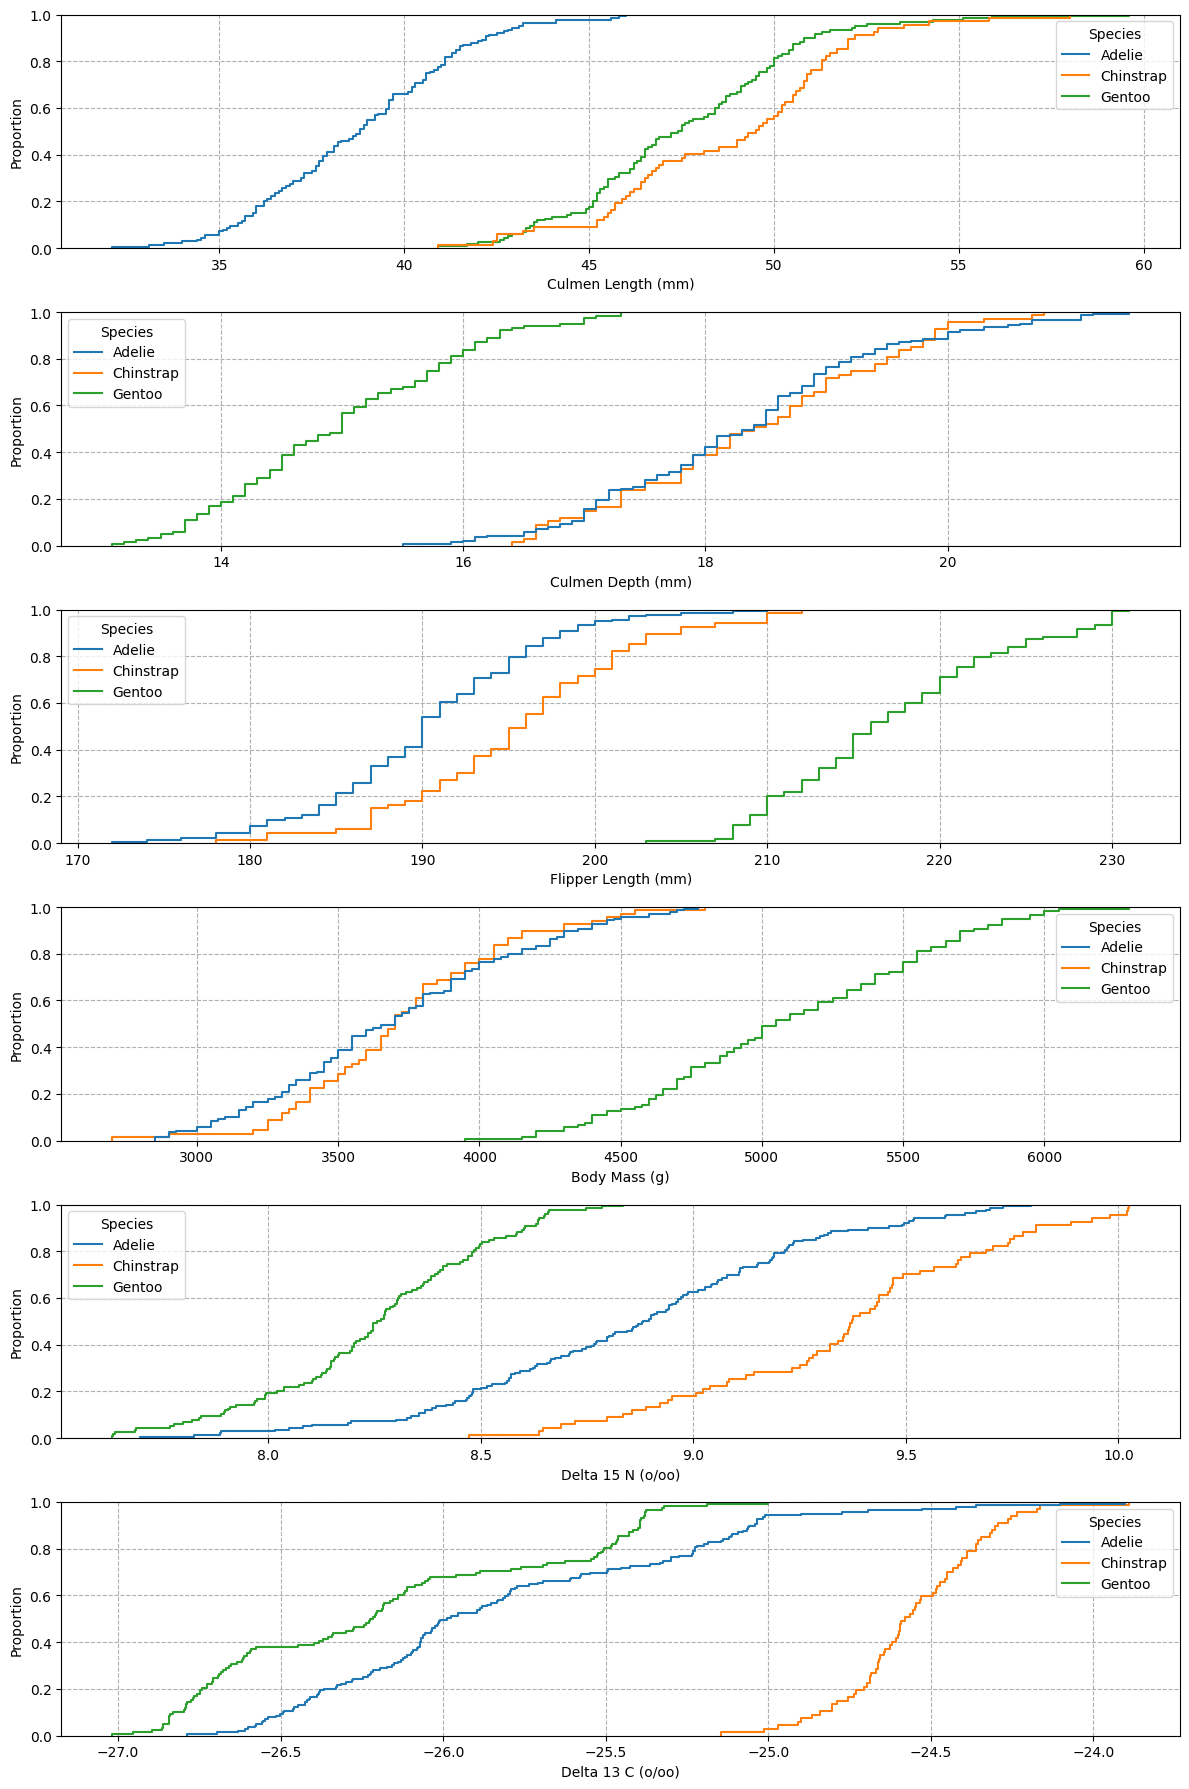

In [23]:
plot_numerical_variable(
    sns.ecdfplot,
    df, 
    numerical_variables,
    hue="Species"
)

### Violin Plots

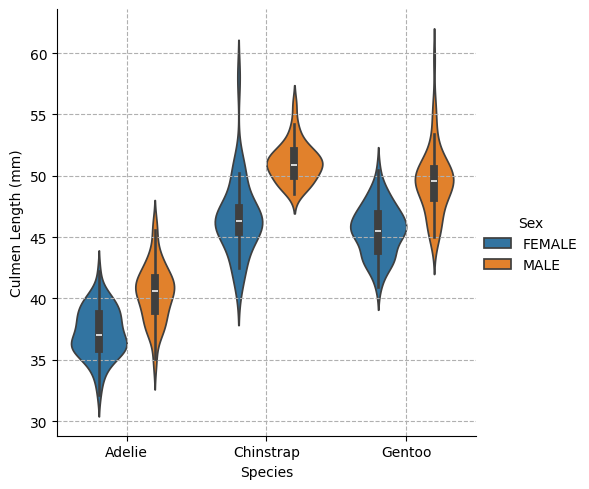

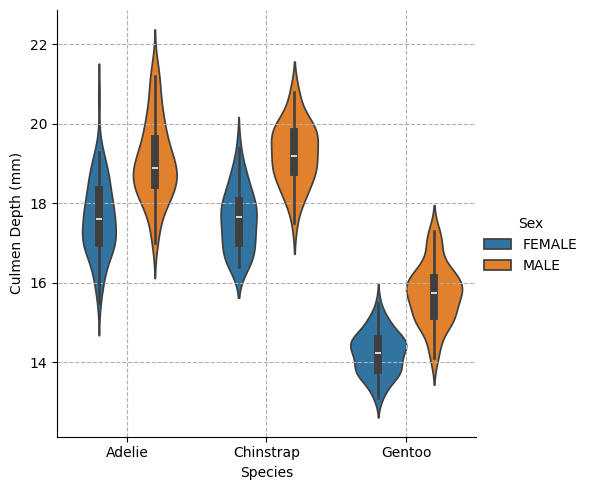

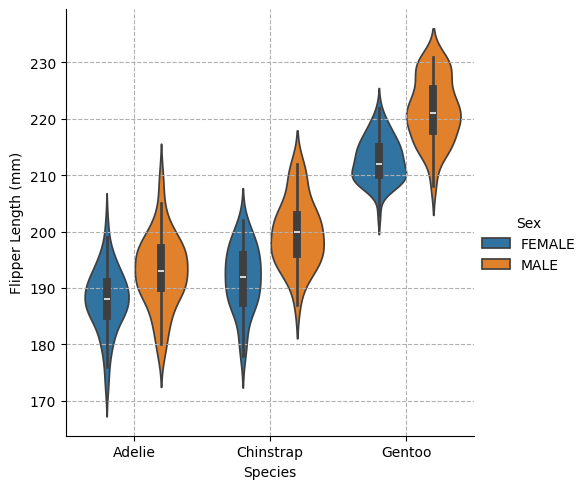

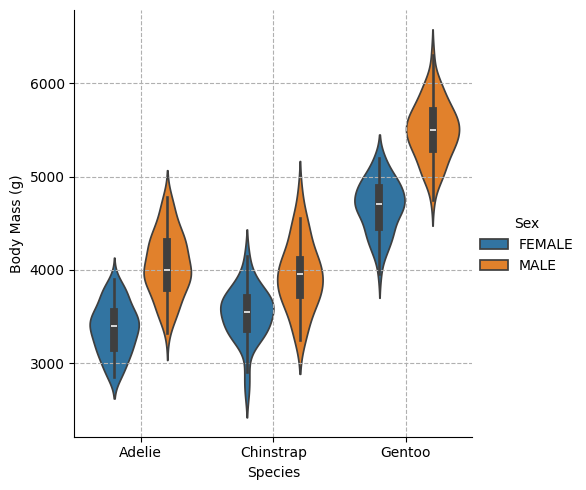

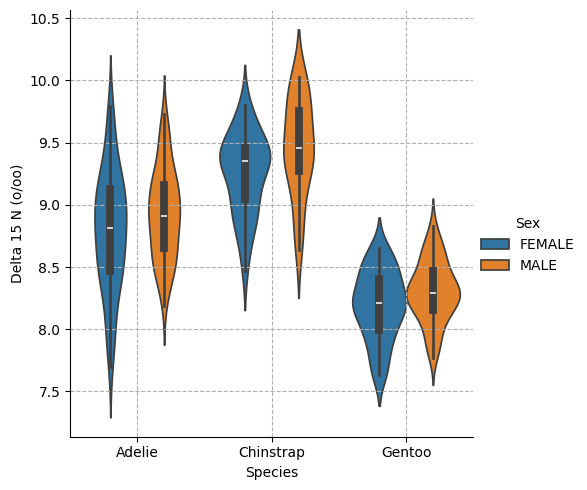

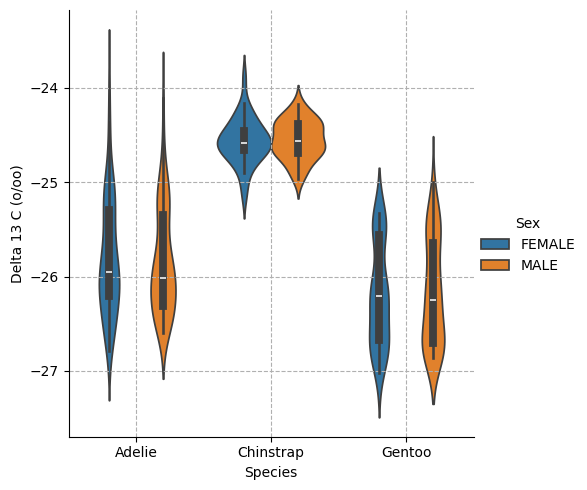

In [24]:
plot_categorical_variable(
    df, numerical_variables,
    x_category="Species",
    hue="Sex",
    kind="violin"
)

### Box-Plots

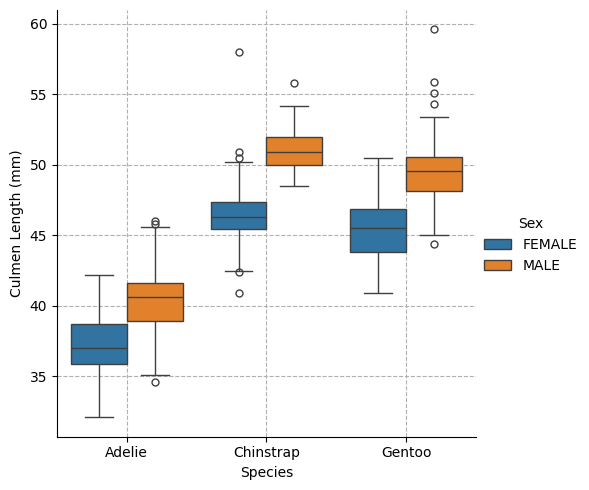

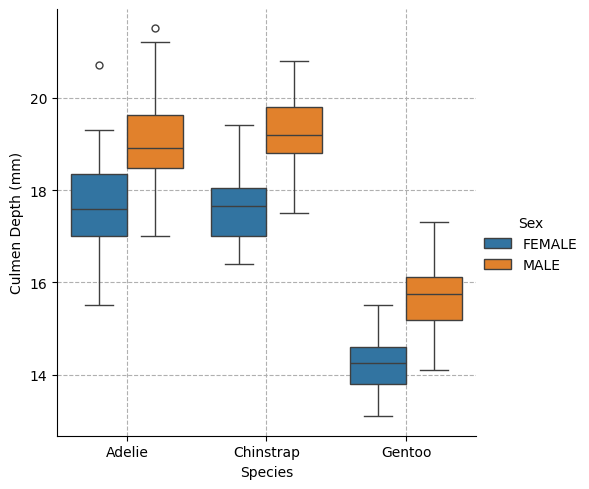

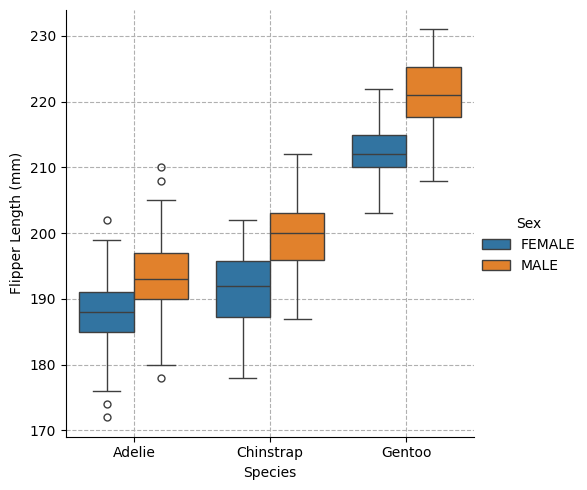

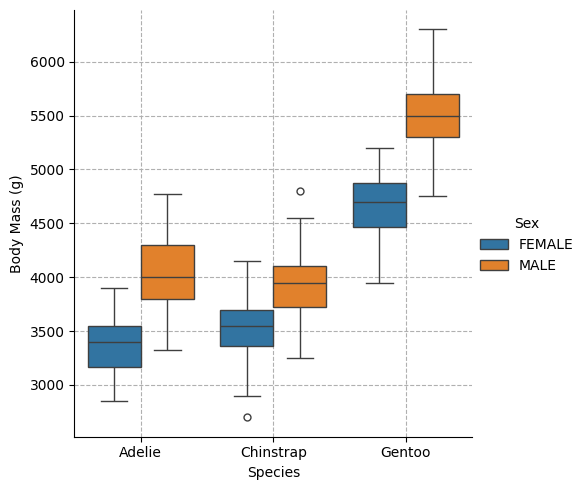

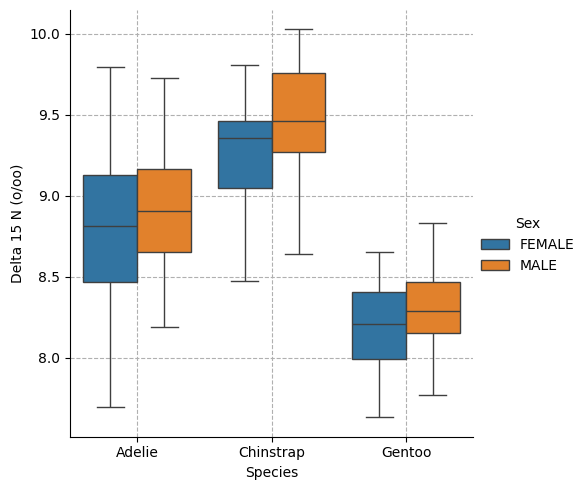

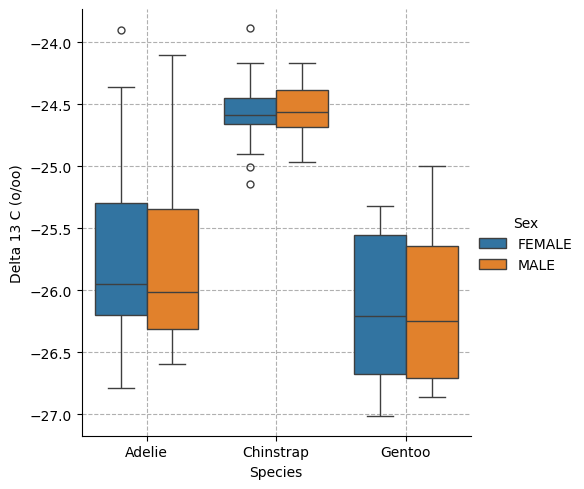

In [25]:
plot_categorical_variable(
    df, numerical_variables,
    x_category="Species",
    hue="Sex",
    kind="box"
)

# Estymacja Parametrów, Przedziały Ufności, Testy

### Estymacja parametrów

In [92]:
from scipy.stats import norm, expon, uniform, bootstrap

In [93]:
def assign_dist_val(dist_name: str, params: tuple[float, float], params_names: tuple[str, str], round_to: int = 3) -> dict[str, float]:
    return {f"{dist_name}_{param_name}": round(param, round_to) for param_name, param in zip(params_names, params)}

In [114]:
stats_dict: dict[str, dict[str, float]] = {}

dists: dict = {
    "norm": {"dist": norm, "params": ["mu", "std"]},
    "expo": {"dist": expon, "params": ["loc", "scale"]},
    "unif": {"dist": uniform, "params": ["a", "b"]},
}

boostrap_confidences: dict[str, dict[str, np.ndarray]] = {}

round_to = 3

In [115]:
for ax_idx, num_var in enumerate(numerical_variables):
    stats_dict[num_var] = {}
    boostrap_confidences[num_var] = {}


    dists_fitted_params: dict[str, tuple] = {
        dist_name: dist["dist"].fit(df[num_var]) for dist_name, dist in dists.items()
    }

    for dist_name, params in dists_fitted_params.items():
        stats_dict[num_var].update({
            f"{dist_name}_{param_name}": round(param, round_to) for param_name, param in zip(dists[dist_name]["params"], params)
        })

        for param_idx, param_name in enumerate(dists[dist_name]["params"]):
            
            boostrap_CI = bootstrap(
                (df[num_var], ),
                statistic=lambda x: dists[dist_name]["dist"].fit(x)[param_idx],
                confidence_level=0.95,
                method='BCa'
            )

            stats_dict[num_var][f"{dist_name}_{param_name}_{"low"}"] = round(boostrap_CI.confidence_interval[0], round_to)
            stats_dict[num_var][f"{dist_name}_{param_name}_{"high"}"] = round(boostrap_CI.confidence_interval[1], round_to)

            boostrap_confidences[num_var][f"{dist_name}_{param_name}"] = boostrap_CI.bootstrap_distribution
            
    



In [112]:
pd.DataFrame(stats_dict).T

,norm_mu,norm_std,norm_mu_low,norm_mu_high,norm_std_low,norm_std_high,expo_loc,expo_scale,expo_loc_low,expo_loc_high,expo_scale_low,expo_scale_high,unif_a,unif_b,unif_a_low,unif_a_high,unif_b_low,unif_b_high
Culmen Length (mm),44.053,5.472,43.438,44.645,5.196,5.817,32.100,11.953,32.100,33.100,11.033,12.991,32.100,27.500,32.100,33.100,26.100,27.500
Culmen Depth (mm),17.127,1.964,16.912,17.340,1.856,2.081,13.100,4.027,13.100,13.200,3.825,4.310,13.100,8.400,13.100,13.200,8.300,8.400
Flipper Length (mm),201.216,13.937,199.707,202.756,13.166,14.737,172.000,29.216,172.000,174.000,27.216,32.051,172.000,59.000,172.000,174.000,58.000,59.000
Body Mass (g),4213.966,808.028,4128.549,4300.000,760.839,859.661,2700.000,1513.966,2700.000,2850.000,1387.191,1677.102,2700.000,3600.000,2700.000,2850.000,3450.000,3600.000
Delta 15 N (o/oo),8.740,0.551,8.681,8.800,0.520,0.586,7.632,1.108,7.632,7.635,1.049,1.175,7.632,2.393,7.632,7.635,2.391,2.393
Delta 13 C (o/oo),-25.689,0.790,-25.774,-25.603,0.750,0.832,-27.019,1.330,-27.019,-26.955,1.245,1.471,-27.019,3.128,-27.019,-26.955,3.115,3.128


(array([6.313e+03, 2.333e+03, 0.000e+00, 8.750e+02, 0.000e+00, 3.090e+02,
        1.500e+02, 0.000e+00, 1.300e+01, 6.000e+00]),
 array([13.1 , 13.16, 13.22, 13.28, 13.34, 13.4 , 13.46, 13.52, 13.58,
        13.64, 13.7 ]),
 <BarContainer object of 10 artists>)

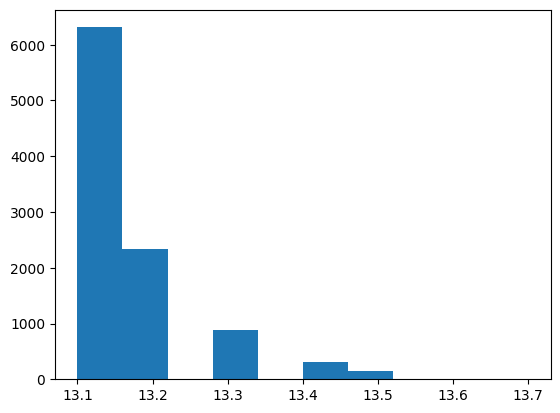

In [120]:
plt.hist(boostrap_confidences["Culmen Depth (mm)"]["unif_a"])